

## Рабочая тетрадь №3

## Задания:



### 1. Докажите через уравнение границы в аналитическом виде, что если использовать евклидову функцию расстояния, то это всегда будет линейной гиперплоскостью.

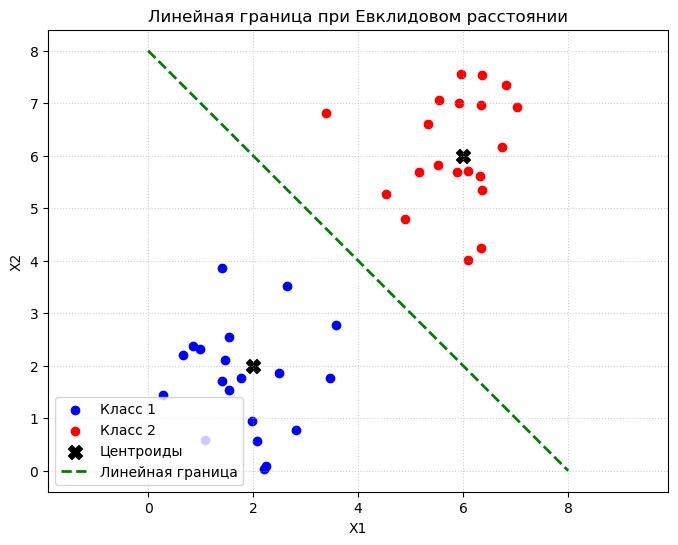

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m1 = np.array([2, 2])
m2 = np.array([6, 6])

class1 = m1 + np.random.randn(20, 2)
class2 = m2 + np.random.randn(20, 2)


w = 2 * (m2 - m1)
b = np.sum(m1**2) - np.sum(m2**2)

x_vals = np.linspace(0, 8, 100)

y_vals = -(w[0] * x_vals + b) / w[1]


plt.figure(figsize=(8, 6))
plt.scatter(class1[:, 0], class1[:, 1], color='blue', label='Класс 1')
plt.scatter(class2[:, 0], class2[:, 1], color='red', label='Класс 2')
plt.scatter([m1[0], m2[0]], [m1[1], m2[1]], color='black', marker='X', s=100, label='Центроиды')

plt.plot(x_vals, y_vals, '--g', linewidth=2, label='Линейная граница')

plt.title("Линейная граница при Евклидовом расстоянии")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')
plt.show()

### 2. Докажите, что косинусная мера близости не зависит от длин сравниваемых векторов.

In [6]:
import numpy as np

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

vec1 = np.array([1, 2, 3])
vec2 = np.array([4, 5, 6])

vec1_long = vec1 * 10
vec2_long = vec2 * 100

print(f"Оригинал: {cosine_similarity(vec1, vec2):.4f}")
print(f"Масштабированные: {cosine_similarity(vec1_long, vec2_long):.4f}")

Оригинал: 0.9746
Масштабированные: 0.9746


### 3. Докажите, что оптимальный константный прогноз, минимизирующий средний квадрат ошибки, это действительно выборочное среднее.



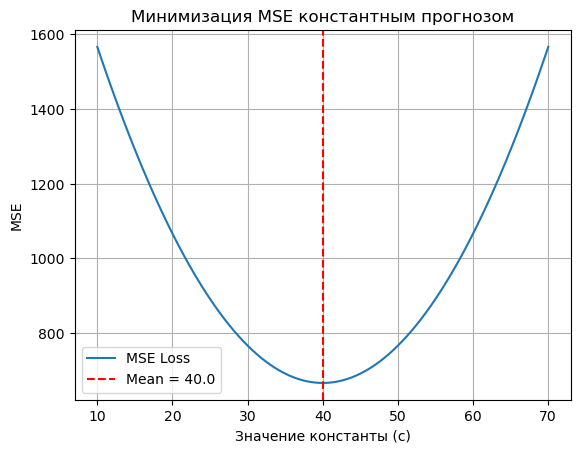

In [8]:
import numpy as np
import matplotlib.pyplot as plt


data = np.array([10, 20, 30, 40, 50, 90])
mean_val = np.mean(data)


c_range = np.linspace(mean_val - 30, mean_val + 30, 100)
mse_values = [np.mean((data - c)**2) for c in c_range]

plt.plot(c_range, mse_values, label='MSE Loss')
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val}')
plt.xlabel('Значение константы (c)')
plt.ylabel('MSE')
plt.title('Минимизация MSE константным прогнозом')
plt.legend()
plt.grid(True)
plt.show()

### 4. Даны по `n` точек для `с` классов обучающей выборки. Выполните классификацию точки `x` в зависимости от `k` с помощью собственной функции.

In [10]:
import numpy as np
from collections import Counter

def classify_knn(x, train_data, labels, k):
  
    distances = []
    
    for i in range(len(train_data)):
        dist = np.sqrt(np.sum((x - train_data[i])**2))
        distances.append((dist, labels[i]))
    
    distances.sort(key=lambda val: val[0])
    
   
    k_nearest = distances[:k]
    
    k_labels = [label for dist, label in k_nearest]
    
  
    most_common = Counter(k_labels).most_common(1)
    
    return most_common[0][0]


class_0 = np.random.rand(5, 2) + [0, 0]  
class_1 = np.random.rand(5, 2) + [2, 2] 

train_data = np.vstack([class_0, class_1])
labels = [0]*5 + [1]*5


new_point = np.array([1.2, 1.2])


result = classify_knn(new_point, train_data, labels, k=3)

print(f"Точка {new_point} классифицирована как класс: {result}")

Точка [1.2 1.2] классифицирована как класс: 0


### 5. Даны два вектора размерности `n`. Напишите собственные функции поиска описанных функции расстояния. 

In [12]:
import math
import numpy as np

def euclidean_distance(v1, v2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(v1, v2)))

def manhattan_distance(v1, v2):
    return sum(abs(a - b) for a, b in zip(v1, v2))

def chebyshev_distance(v1, v2):
    return max(abs(a - b) for a, b in zip(v1, v2))

def cosine_distance(v1, v2):
    v1, v2 = np.array(v1), np.array(v2)
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    
    if norm_v1 == 0 or norm_v2 == 0:
        return 1.0
    similarity = dot_product / (norm_v1 * norm_v2)
    return 1 - similarity


vec_a = [1, 2, 3]
vec_b = [4, 5, 6]

print(f"Вектор A: {vec_a}, Вектор B: {vec_b}\n")
print(f"Евклидово:  {euclidean_distance(vec_a, vec_b):.4f}")
print(f"Манхэттен:  {manhattan_distance(vec_a, vec_b):.4f}")
print(f"Чебышёв:    {chebyshev_distance(vec_a, vec_b):.4f}")
print(f"Косинусное: {cosine_distance(vec_a, vec_b):.4f}")

Вектор A: [1, 2, 3], Вектор B: [4, 5, 6]

Евклидово:  5.1962
Манхэттен:  9.0000
Чебышёв:    3.0000
Косинусное: 0.0254


### 6. Дано `n` точек. Спрогнозируйте значение в `x` при k-NN регрессии для `k` соседей.

In [14]:
import numpy as np

def knn_regressor(x_new, x_train, y_train, k):
    distances = []
    
    for i in range(len(x_train)):
        dist = np.linalg.norm(x_new - x_train[i])
        distances.append((dist, y_train[i]))
    

    distances.sort(key=lambda val: val[0])

    k_nearest_values = [val[1] for val in distances[:k]]

    prediction = np.mean(k_nearest_values)
    
    return prediction


X_train = np.array([[1], [2], [3], [4], [5]])
Y_train = np.array([2.1, 3.9, 6.2, 8.1, 10.5])

X_query = np.array([3.5]) 
K = 2

res = knn_regressor(X_query, X_train, Y_train, K)
print(f"Прогноз для x={X_query[0]} при k={K}: {res:.2f}")

Прогноз для x=3.5 при k=2: 7.15


### 7. Даны `n` классов с `m` точек.
- Найдите центроиды для каждого класса с помощью собственной функции.
- Найдите, к какому классу будет отнесена точка `x` с помощью собственной функции.

In [16]:
import numpy as np

def calculate_centroids(classes_data):
    centroids = {}
    for class_name, points in classes_data.items():
        points_array = np.array(points)
        centroids[class_name] = np.mean(points_array, axis=0)
    return centroids

def predict_class(x, centroids):
    
    min_dist = float('inf')
    
    for class_name, centroid in centroids.items():
        dist = np.linalg.norm(x - centroid)
        
        if dist < min_dist:
            min_dist = dist
            best_class = class_name
            
    return best_class


training_data = {
    "A": [[1, 1], [2, 1], [1, 2]],
    "B": [[8, 8], [9, 7], [8, 9]]
}


all_centroids = calculate_centroids(training_data)
for cls, ctr in all_centroids.items():
    print(f"Центроид класса {cls}: {ctr}")


new_x = np.array([3, 2])
result = predict_class(new_x, all_centroids)

print(f"\nТочка {new_x} отнесена к классу: {result}")

Центроид класса A: [1.33333333 1.33333333]
Центроид класса B: [8.33333333 8.        ]

Точка [3 2] отнесена к классу: A
